# 01 Import libraries

In [1]:
import os
import warnings
from json import loads

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from snowflake.snowpark import Session

warnings.simplefilter("ignore")

# 02 Download data

In [4]:
path_in = '../data/input/'
path_out =  '../data/output/'
paths = [path_in, path_out]

for path in paths:
    os.makedirs(path, exist_ok=True)

In [3]:
data_mwo = pd.read_csv(os.path.join(path_in, 'mwo_dataset.csv'))

#  03 EDA

In [4]:
data_mwo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   mach           20000 non-null  object
 1   date_received  20000 non-null  object
 2   issue          20000 non-null  object
 3   info           20000 non-null  object
 4   tech           20000 non-null  object
dtypes: object(5)
memory usage: 781.4+ KB


In [5]:
data_mwo.drop(columns='date_received').describe()

,mach,issue,info,tech
count,20000,20000,20000,20000
unique,99,24,144,6
top,A38,Spindle indexing error with overfeed,Michele Williams noted: Seal on saw attachment...,"angie_henderson, michele_williams"
freq,255,896,175,3405


In [6]:
data_mwo.head()

,mach,date_received,issue,info,tech
0,A71,04/03/2015,Machine is unpowered,Gina Moore noted: Rewiring done on threading u...,"gina_moore, dylan_miller"
1,A6,14/09/2015,Leak in side B hydraulic line,Cristian Santos noted: No further details.,cristian_santos
2,A61,25/03/2015,Leak in side B hydraulic line,Angie Henderson noted: Completed rewiring of t...,"angie_henderson, michele_williams"
3,A3,06/04/2015,Spindle indexing error with overfeed,Ethan Adams noted: Turrets dismantled and chip...,"ethan_adams, michele_williams"
4,A47,08/07/2015,Gears on the saw attachment are too tight and ...,Nathan Maldonado noted: Completed rewiring of ...,nathan_maldonado


# 04 Transform

## 04.01 AI Classification

In [ ]:
CREATE OR REPLACE TABLE KAGGLE_DATABASE.MAINTENANCE_DATASETS.WORK_ORDER_PRIMARY_CLASSIFICATION AS

SELECT *,
SNOWFLAKE.CORTEX.AI_COMPLETE(model => 'claude-4-sonnet', 
                             prompt => CONCAT('<CONTEXT>As a senior reliability engineering expert, you want to classify the failures within this text'
                                              , FAILURE_DATA, 
                                              '</CONTEXT><OUTPUT>Classify the failure in no more than 3 words.</OUTPUT>'),
                             model_parameters => {
                                        'temperature': 0.5
                                    }) AS FAILURE_CLASSIFICATION
FROM KAGGLE_DATABASE.MAINTENANCE_DATASETS.WORK_ORDERS_TABLE;

In [12]:
# first you need to configure the snowflake cli
session = Session.builder.config("connection_name", "snow-connection").create()


df_table = session.table("KAGGLE_DATABASE.MAINTENANCE_DATASETS.WORK_ORDER_PRIMARY_CLASSIFICATION").select("MACH", "ISSUE", "FAILURE_CLASSIFICATION")
df_table.show(3)

------------------------------------------------------------------------------------------------
|"MACH"  |"ISSUE"                                             |"FAILURE_CLASSIFICATION"        |
------------------------------------------------------------------------------------------------
|A47     |Gears on the saw attachment are too tight and g...  |"Gear binding failure"          |
|A17     |Saw attachment is leaking hydraulics                |"Hydraulic fluid leak"          |
|A90     |Accumulators need checking and charging             |"Accumulator charging failure"  |
------------------------------------------------------------------------------------------------



## 04.02 Failure mode category

In [5]:
# data_primary_class = df_table.to_pandas()
# data_primary_class.to_csv(os.path.join(path_out, 'data_primary_class.csv'), index=False)
data_primary_class = pd.read_csv(os.path.join(path_out, 'data_primary_class.csv'))

In [6]:
df = data_primary_class[data_primary_class['FAILURE_CLASSIFICATION'].isin(data_primary_class['FAILURE_CLASSIFICATION'].value_counts()[:20].keys().to_list())]

In [7]:
pd.set_option('display.max_colwidth', 1000)
df[['ISSUE', 'FAILURE_CLASSIFICATION']].sample(20)

,ISSUE,FAILURE_CLASSIFICATION
1973,Hydraulic line leak on side B,"""Hydraulic line leak"""
8936,Leak detected in hydraulic line of saw attachment,"""Hydraulic line leak"""
18056,Maintenance on milling spindle needed,"""Spindle maintenance required"""
2197,Inspect and recharge accumulators,"""Control pendant failure"""
6431,Saw attachment gears are binding and grinding,"""Mechanical gear binding"""
19939,Gears on the saw attachment are too tight and grinding,"""Gear binding failure"""
18368,Hydraulic line leak on side B,"""Hydraulic line leak"""
19188,Saw attachment gears are binding and grinding,"""Mechanical gear binding"""
14443,Accumulator inspection and charging required,"""Hydraulic seal failure"""
17900,Hydraulic fluid leak at saw attachment,"""Hydraulic fluid leak"""


In [8]:
data_primary_class['FAILURE_CLASSIFICATION'].value_counts()

FAILURE_CLASSIFICATION
"Hydraulic line leak"                    1659
"Hydraulic fluid leak"                   1423
"Spindle indexing failure"               1348
"Hydraulic seal failure"                 1155
"Accumulator maintenance required"        966
                                         ... 
"Accumulator maintenance replacement"       1
"Power Loss Failure"                        1
"Mechanical seal failure"                   1
"INDEXING SYSTEM FAILURE"                   1
"Seal Failure"                              1
Name: count, Length: 260, dtype: int64

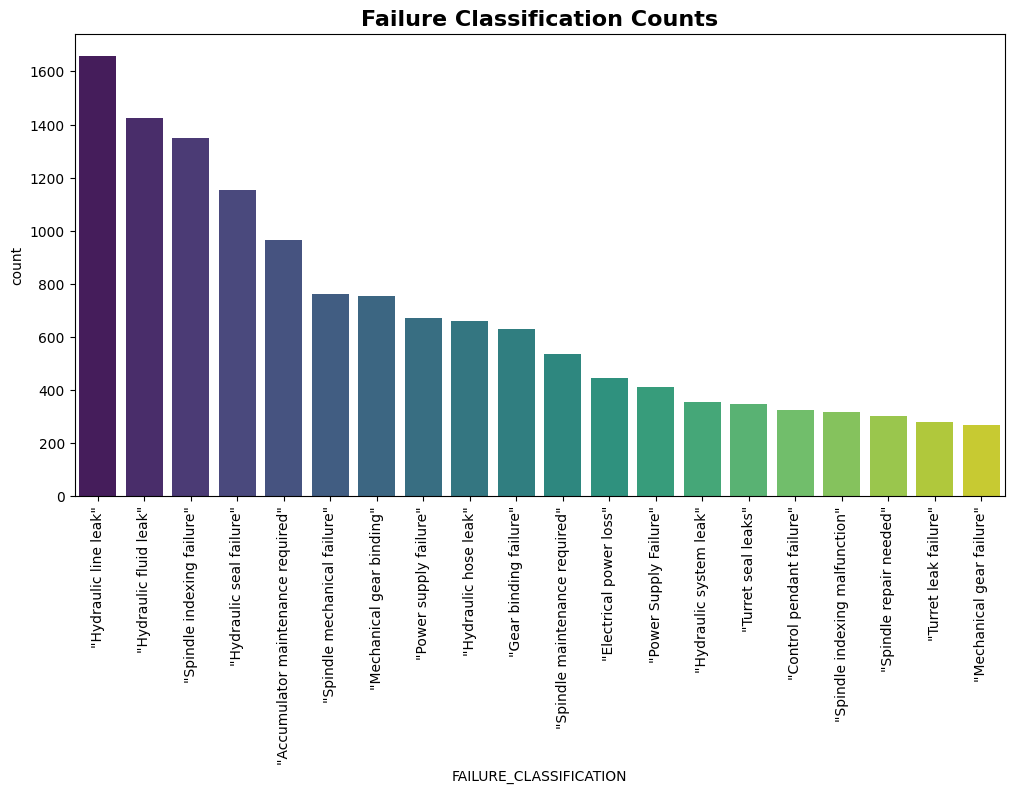

In [9]:
# Create static plot using seaborn and matplotlib
plt.figure(figsize=(12, 6))
g = sns.countplot(data=df, x='FAILURE_CLASSIFICATION', palette='viridis', order = df['FAILURE_CLASSIFICATION'].value_counts().index)
plt.title('Failure Classification Counts', fontsize=16, fontweight='bold')
plt.setp(g.get_xticklabels(), rotation=90)

plt.show()

## 04.03 Reduce the number of category

In [10]:
data_reduce_cat = pd.read_excel(os.path.join(path_out, 'reduce_categories_result.xlsx'), sheet_name='8_50')

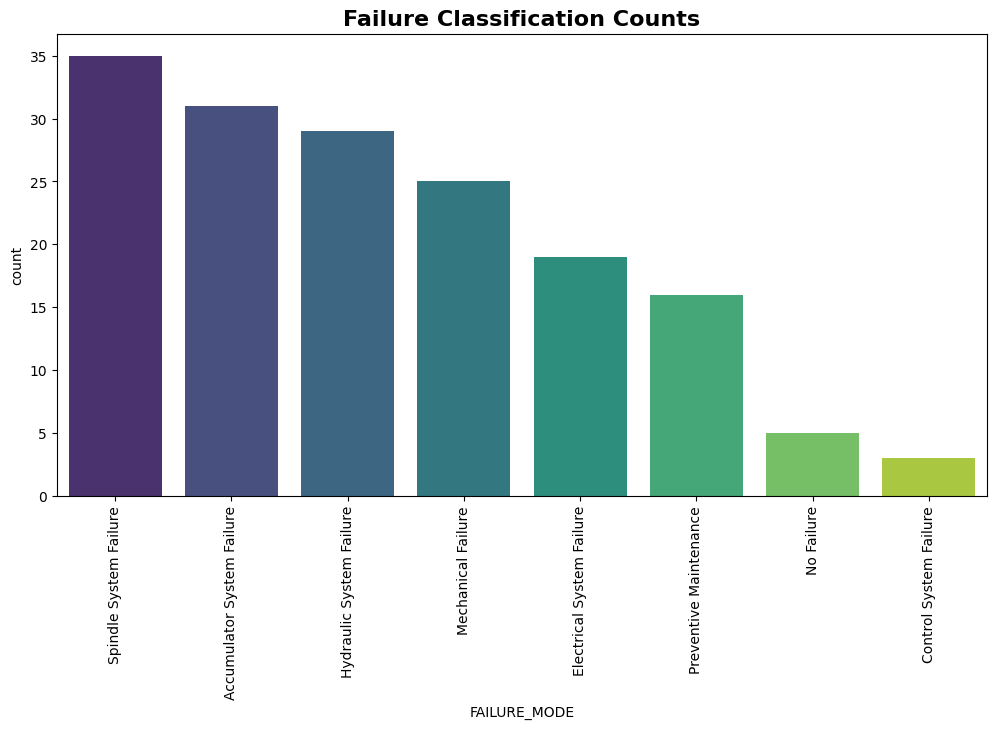

In [11]:
# Create static plot using seaborn and matplotlib
plt.figure(figsize=(12, 6))
g = sns.countplot(data=data_reduce_cat, x='FAILURE_MODE', palette='viridis', order = data_reduce_cat['FAILURE_MODE'].value_counts().index)
plt.title('Failure Classification Counts', fontsize=16, fontweight='bold')
plt.setp(g.get_xticklabels(), rotation=90)

plt.show()